# Analysis Figures and Tables — v2
## Pollinator Traits, Temporal Patterns and Pollination Success — Zurich Urban Gardens

**Dataset:** Reji Chacko, Moretti & Frey (2025) *Data in Brief* 62: 112013  
**Input:** `master_table_model_ready_v2.csv`

I produce eight figures and one summary table. The sequence moves from descriptive context (Figs 1–3), to benchmark replication (Fig 4), to my novel trait analyses (Figs 4, 5, 8), to temporal patterns (Fig 8), and finally to a synthesis table (Table 1) that compares all predictor types side by side.

| Figure | Research question addressed |
|---|---|
| Fig 1 | What does pollination success look like across gardens and plants? |
| Fig 2 | Who visits each plant, and which bee type dominates? |
| Fig 3 | Do visitor trait profiles already differ by plant species? |
| **Fig 4** | Does the JAE paper benchmark abundance predictor replicate my correlations? |
| Fig 5 | Does bee tongue length predict success on specialist flowers? |
| Fig 6 | Does bee body size predict success (exploratory)? |
| **Fig 7** | Do social bees predict success better than solitary bees? |
| Fig 8 | Does morning visitation predict success? |
| Table 1 | Which predictor type explains the most variance per plant? |


## Setup — Imports and Shared Style

In [ ]:
import matplotlib; matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np, pandas as pd
from scipy import stats

COLORS = {'Carrot':'#E07B39','Radish':'#C0396E','Sainfoin':'#4A9E6B','Comfrey':'#5B6FA6'}
PLANT_ORDER = ['Carrot','Radish','Sainfoin','Comfrey']
PLANT_LABELS = {'Carrot':'Wild Carrot\n(exposed)','Radish':'Radish\n(partly concealed)',
                'Sainfoin':'Sainfoin\n(concealed)','Comfrey':'Comfrey\n(deeply concealed)'}
GROUP_COLORS = {'bee':'#F4A261','hoverfly':'#2A9D8F','wasp':'#E9C46A','beetle':'#6C757D'}
SOC_COLORS   = {'honeybee':'#E74C3C','social_bee':'#F4A261','solitary_bee':'#85C1E9','unclassified_bee':'#BDC3C7'}
plt.rcParams.update({'font.family':'DejaVu Sans','axes.spines.top':False,'axes.spines.right':False,
    'axes.facecolor':'white','figure.facecolor':'#f9fafb','axes.grid':True,'grid.alpha':0.35,'font.size':11})

def ann_r(ax,r,p,n,x=0.05,y=0.97):
    sig='***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else '.' if p<0.10 else 'ns'
    col='#C0392B' if p<0.05 else ('#E67E22' if p<0.10 else '#666')
    ax.text(x,y,f'r = {r:+.3f}\np = {p:.3f} {sig}\nn = {n}',transform=ax.transAxes,va='top',fontsize=10,color=col,
            bbox=dict(boxstyle='round,pad=0.3',facecolor='white',alpha=0.85,edgecolor='#ddd'))

master = pd.read_csv('master_table_model_ready_v2.csv')
print(f'Loaded: {master.shape}  |  {master["phytometer_plant"].value_counts().to_dict()}')


Loaded: (96, 40)  |  {'Carrot': 24, 'Radish': 24, 'Sainfoin': 24, 'Comfrey': 24}


## Figure 1 — Pollination Success by Plant Species

I produce this figure to establish the outcome I am trying to explain. Carrot appears in a separate panel because its metric (seeds per umbel, ~80–280) is on a different scale from the fruit set proportions (0–1) of the other three plants. Placing them in the same axis would mislead readers about the relative magnitudes. The jittered individual points show the full distribution; box plots show the central tendency.

> **Expected:** Comfrey shows the widest garden-to-garden spread. Sainfoin shows the lowest mean and highest proportional variance. × symbols mark sainfoin caution-flagged gardens.

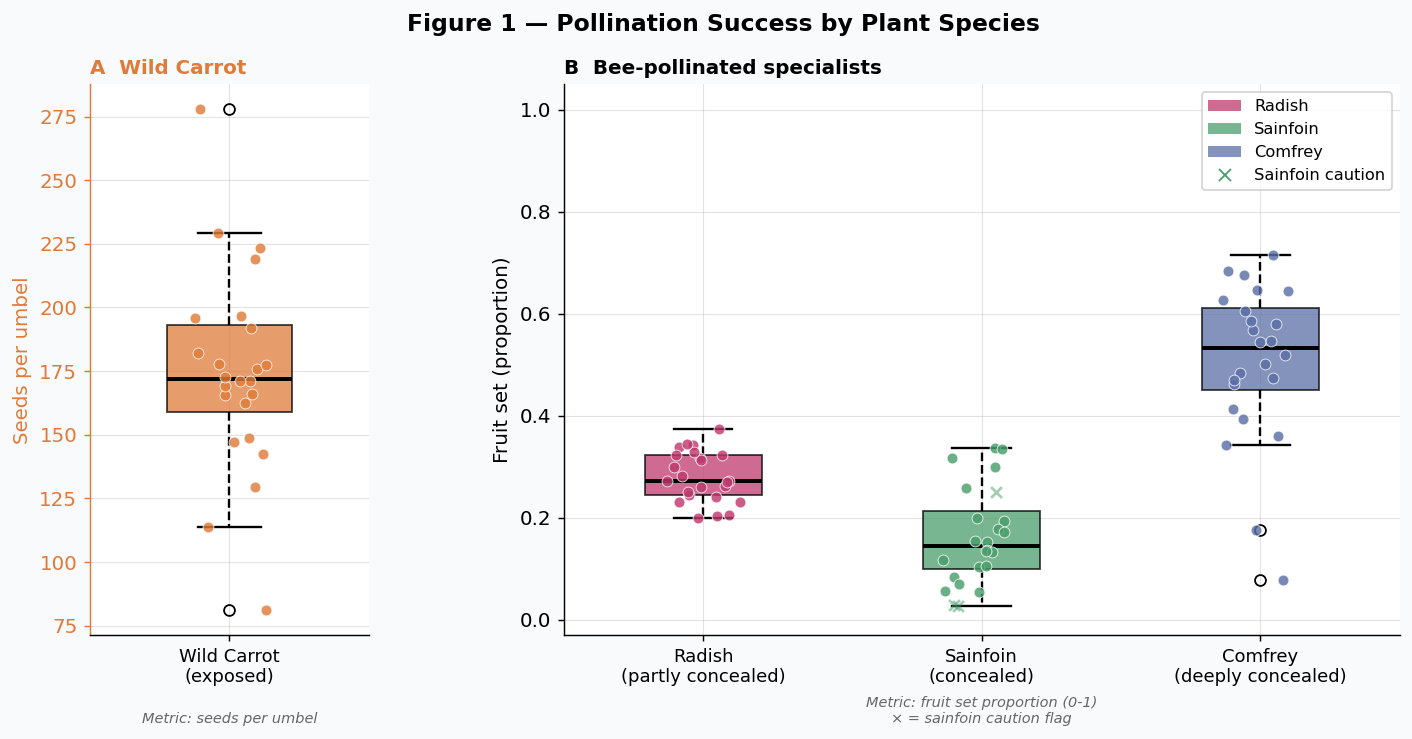

In [ ]:
fig,gs=plt.figure(figsize=(13,5.5)),None
fig.suptitle('Figure 1 — Pollination Success by Plant Species',fontsize=13,fontweight='bold')
gs=fig.add_gridspec(1,2,width_ratios=[1,3],wspace=0.35)
axL=fig.add_subplot(gs[0]);axR=fig.add_subplot(gs[1])
rng=np.random.default_rng(42)
cv=master[master['phytometer_plant']=='Carrot']['pollination_success'].dropna().values
bp0=axL.boxplot([cv],patch_artist=True,widths=0.45,medianprops=dict(color='black',linewidth=2.2),whiskerprops=dict(linewidth=1.3,linestyle='--'),capprops=dict(linewidth=1.3))
bp0['boxes'][0].set_facecolor(COLORS['Carrot']);bp0['boxes'][0].set_alpha(0.75)
axL.scatter(np.full(len(cv),1)+rng.uniform(-0.14,0.14,len(cv)),cv,color=COLORS['Carrot'],s=36,alpha=0.82,edgecolors='white',linewidth=0.5,zorder=3)
axL.set_xticks([1]);axL.set_xticklabels(['Wild Carrot\n(exposed)'],fontsize=10)
axL.set_ylabel('Seeds per umbel',fontsize=11,color=COLORS['Carrot']);axL.tick_params(axis='y',colors=COLORS['Carrot']);axL.spines['left'].set_color(COLORS['Carrot'])
axL.set_title('A  Wild Carrot',fontsize=11,loc='left',fontweight='bold',color=COLORS['Carrot'])
other=['Radish','Sainfoin','Comfrey']
bpR=axR.boxplot([master[master['phytometer_plant']==p]['pollination_success'].dropna().values for p in other],patch_artist=True,widths=0.42,medianprops=dict(color='black',linewidth=2.2),whiskerprops=dict(linewidth=1.3,linestyle='--'),capprops=dict(linewidth=1.3))
for patch,p in zip(bpR['boxes'],other):patch.set_facecolor(COLORS[p]);patch.set_alpha(0.75)
for i,p in enumerate(other,1):
    vals=master[master['phytometer_plant']==p]['pollination_success'].dropna().values
    if p=='Sainfoin':
        lo=master[(master['phytometer_plant']==p)&(master['sainfoin_caution_flag']==True)]['pollination_success'].dropna().values
        hi=master[(master['phytometer_plant']==p)&(master['sainfoin_caution_flag']==False)]['pollination_success'].dropna().values
        axR.scatter(np.full(len(lo),i)+rng.uniform(-0.14,0.14,len(lo)),lo,color=COLORS[p],s=36,alpha=0.5,marker='x',zorder=3)
        axR.scatter(np.full(len(hi),i)+rng.uniform(-0.14,0.14,len(hi)),hi,color=COLORS[p],s=36,alpha=0.82,edgecolors='white',linewidth=0.5,zorder=3)
    else:
        axR.scatter(np.full(len(vals),i)+rng.uniform(-0.14,0.14,len(vals)),vals,color=COLORS[p],s=36,alpha=0.82,edgecolors='white',linewidth=0.5,zorder=3)
axR.set_xticks([1,2,3]);axR.set_xticklabels([PLANT_LABELS[p] for p in other],fontsize=10)
axR.set_ylabel('Fruit set (proportion)');axR.set_ylim(-0.03,1.05)
axR.set_title('B  Bee-pollinated specialists',fontsize=11,loc='left',fontweight='bold')
handles=[mpatches.Patch(facecolor=COLORS[p],alpha=0.75,label=p) for p in other]
handles.append(plt.Line2D([0],[0],marker='x',color=COLORS['Sainfoin'],linestyle='None',markersize=7,label='Sainfoin caution'))
axR.legend(handles=handles,loc='upper right',fontsize=9)
plt.tight_layout();plt.show()

## Figure 2 — Pollinator Community Composition by Plant Species

I produce Figure 2 to show that flower morphology filters who visits each plant — a necessary foundation for interpreting the trait scatter plots. **Panel A** shows that carrot attracts the most diverse community; comfrey and sainfoin are dominated by bees. **Panel B** shows garden-level bee proportion variation. **Panel C** (new in this version) breaks bee visits down by sociality, showing that social bees (mainly bumblebees) dominate comfrey and radish — directly justifying why the JAE paper used social bee abundance, not total bee abundance, as the benchmark predictor for those plants.

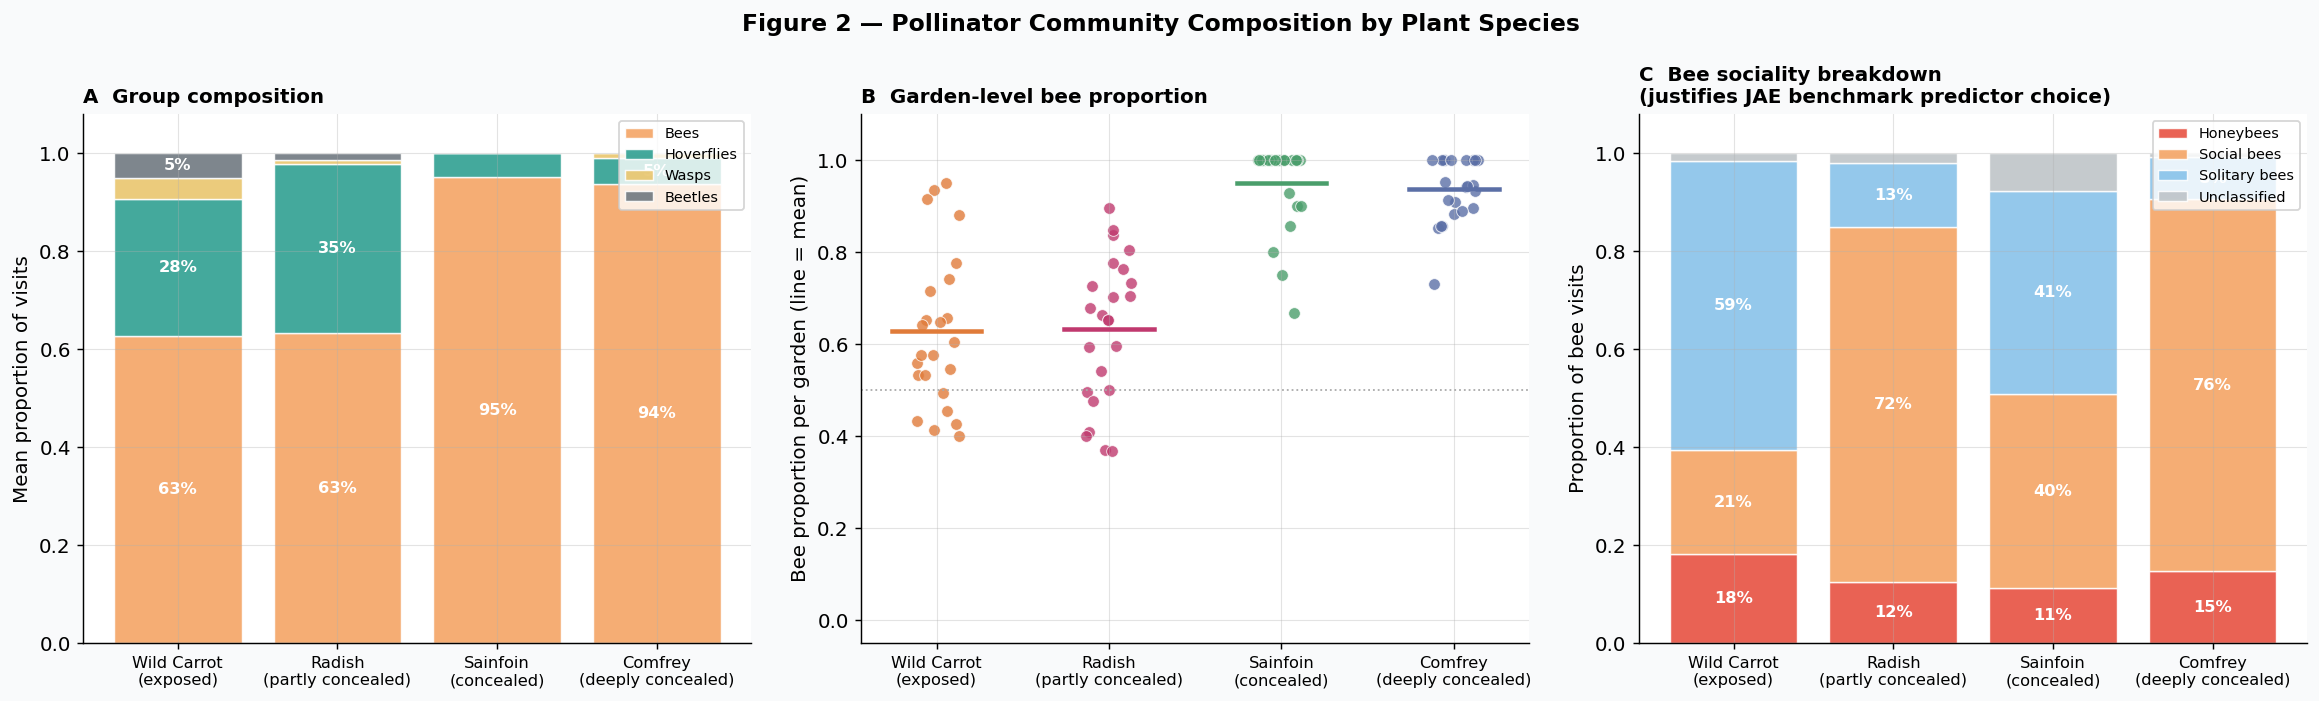

In [ ]:
comp=master.groupby('phytometer_plant')[['bee_proportion','hoverfly_proportion','wasp_proportion','beetle_proportion',
    'honeybee_visits','social_bee_visits','solitary_bee_visits','unclassified_bee_visits']].mean().reindex(PLANT_ORDER)
fig,axes=plt.subplots(1,3,figsize=(18,5.5))
fig.suptitle('Figure 2 — Pollinator Community Composition by Plant Species',fontsize=13,fontweight='bold')
ax,bottom=axes[0],np.zeros(4)
for col,lbl,gcol in [('bee_proportion','Bees','#F4A261'),('hoverfly_proportion','Hoverflies','#2A9D8F'),
                     ('wasp_proportion','Wasps','#E9C46A'),('beetle_proportion','Beetles','#6C757D')]:
    vals=comp[col].values
    ax.bar(range(4),vals,bottom=bottom,color=gcol,alpha=0.88,label=lbl,edgecolor='white',linewidth=0.8)
    for xi,(v,b) in enumerate(zip(vals,bottom)):
        if v>0.05: ax.text(xi,b+v/2,f'{v*100:.0f}%',ha='center',va='center',fontsize=9,color='white',fontweight='bold')
    bottom+=vals
ax.set_xticks(range(4));ax.set_xticklabels([PLANT_LABELS[p] for p in PLANT_ORDER],fontsize=9)
ax.set_ylabel('Mean proportion of visits');ax.set_ylim(0,1.08);ax.legend(loc='upper right',fontsize=8)
ax.set_title('A  Group composition',fontsize=11,loc='left',fontweight='bold')
ax2=axes[1];rng=np.random.default_rng(0)
for i,p in enumerate(PLANT_ORDER):
    sub=master[master['phytometer_plant']==p]['bee_proportion'].dropna()
    ax2.scatter(np.full(len(sub),i)+rng.uniform(-0.14,0.14,len(sub)),sub,color=COLORS[p],s=42,alpha=0.8,edgecolors='white',linewidth=0.5)
    ax2.plot([i-0.26,i+0.26],[sub.mean(),sub.mean()],color=COLORS[p],linewidth=2.5)
ax2.set_xticks(range(4));ax2.set_xticklabels([PLANT_LABELS[p] for p in PLANT_ORDER],fontsize=9)
ax2.set_ylabel('Bee proportion per garden (line = mean)');ax2.set_ylim(-0.05,1.1)
ax2.set_title('B  Garden-level bee proportion',fontsize=11,loc='left',fontweight='bold')
ax3=axes[2];bottom3=np.zeros(4)
bee_tots=comp[['honeybee_visits','social_bee_visits','solitary_bee_visits','unclassified_bee_visits']].sum(axis=1)
for col,lbl,sc in [('honeybee_visits','Honeybees','#E74C3C'),('social_bee_visits','Social bees','#F4A261'),
                   ('solitary_bee_visits','Solitary bees','#85C1E9'),('unclassified_bee_visits','Unclassified','#BDC3C7')]:
    props=comp[col].values/bee_tots.values.clip(min=1)
    ax3.bar(range(4),props,bottom=bottom3,color=sc,alpha=0.88,label=lbl,edgecolor='white',linewidth=0.8)
    for xi,(v,b) in enumerate(zip(props,bottom3)):
        if v>0.08: ax3.text(xi,b+v/2,f'{v*100:.0f}%',ha='center',va='center',fontsize=9,color='white',fontweight='bold')
    bottom3+=props
ax3.set_xticks(range(4));ax3.set_xticklabels([PLANT_LABELS[p] for p in PLANT_ORDER],fontsize=9)
ax3.set_ylabel('Proportion of bee visits');ax3.set_ylim(0,1.08);ax3.legend(loc='upper right',fontsize=8)
ax3.set_title('C  Bee sociality breakdown',fontsize=11,loc='left',fontweight='bold')
plt.tight_layout();plt.show()


## Figure 3 — CWM Bee Trait Profiles by Plant Species

I produce Figure 3 to show that the trait-matching pattern is already visible in the raw community data, before any correlation analysis. Bees visiting comfrey and sainfoin have longer tongues on average than bees visiting carrot — because the flower structure already filters which bees can access the nectar. This makes the significant correlation in Figure 5 expected rather than surprising.

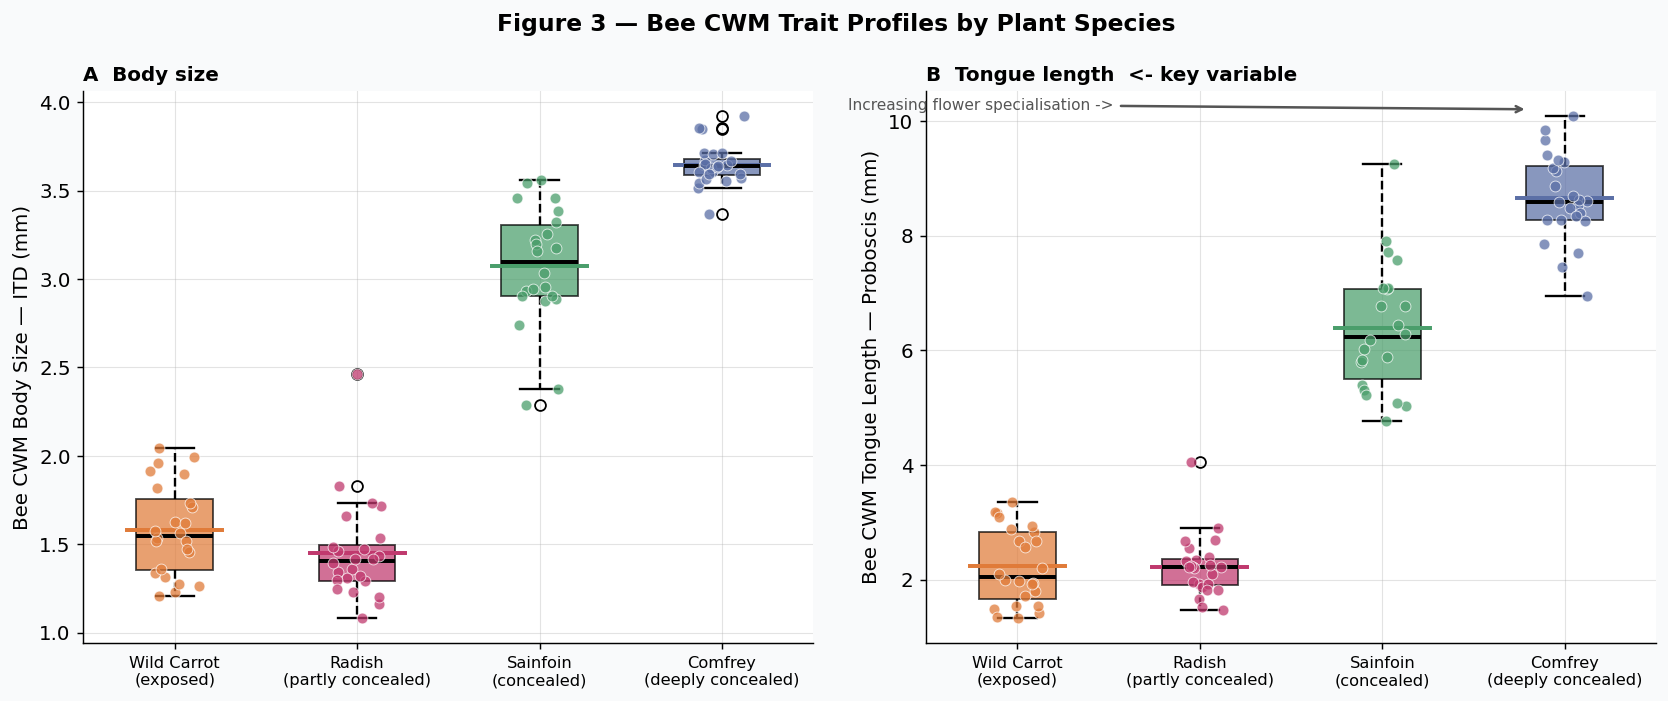

In [ ]:
fig,axes=plt.subplots(1,2,figsize=(13,5.5))
fig.suptitle('Figure 3 — CWM Bee Trait Profiles by Plant Species',fontsize=13,fontweight='bold')
rng=np.random.default_rng(1)
for ax,(col,ylabel,title) in zip(axes,[('bee_mean_intertegular_distance','Bee CWM Body Size - ITD (mm)','A  Body size'),('bee_mean_proboscis_length','Bee CWM Tongue Length - Proboscis (mm)','B  Tongue length <- key variable')]):
    bpd=[master[master['phytometer_plant']==p][col].dropna().values for p in PLANT_ORDER]
    bp=ax.boxplot(bpd,patch_artist=True,widths=0.42,medianprops=dict(color='black',linewidth=2.2),whiskerprops=dict(linewidth=1.3,linestyle='--'),capprops=dict(linewidth=1.3))
    for patch,p in zip(bp['boxes'],PLANT_ORDER):patch.set_facecolor(COLORS[p]);patch.set_alpha(0.72)
    for i,(vals,p) in enumerate(zip(bpd,PLANT_ORDER),1):
        if len(vals)==0:continue
        ax.scatter(np.full(len(vals),i)+rng.uniform(-0.14,0.14,len(vals)),vals,color=COLORS[p],s=36,alpha=0.75,edgecolors='white',linewidth=0.5,zorder=3)
        ax.plot([i-0.26,i+0.26],[np.mean(vals),np.mean(vals)],color=COLORS[p],linewidth=2.2)
    ax.set_xticks([1,2,3,4]);ax.set_xticklabels([PLANT_LABELS[p] for p in PLANT_ORDER],fontsize=9)
    ax.set_ylabel(ylabel,fontsize=11);ax.set_title(title,fontsize=11,loc='left',fontweight='bold')
plt.tight_layout();plt.show()


## Figure 4 — Benchmark Replication (JAE Figure S6 Direction)

I produce Figure 4 to test whether the JAE paper's benchmark predictors (Reji Chacko et al., 2026, Figure S6) replicate in my garden-level Pearson correlations. The JAE paper found using Bayesian GLMMs that: hoverfly abundance → carrot; social bee abundance → radish and comfrey; total bee abundance → sainfoin. I use `focal_group_visits_benchmark` which holds the appropriate predictor per row. If my correlations match the JAE direction (positive for all), this validates my data pipeline and sets the benchmark R² that my trait analysis must compete against in Table 1.

> **Important:** I report Pearson r, not Bayesian credible intervals. My correlations may not reach p < 0.05 even when the JAE paper's models found credible effects, because I do not control for sampling effort, random effects, or spatial autocorrelation. I treat direction as the primary comparison criterion.

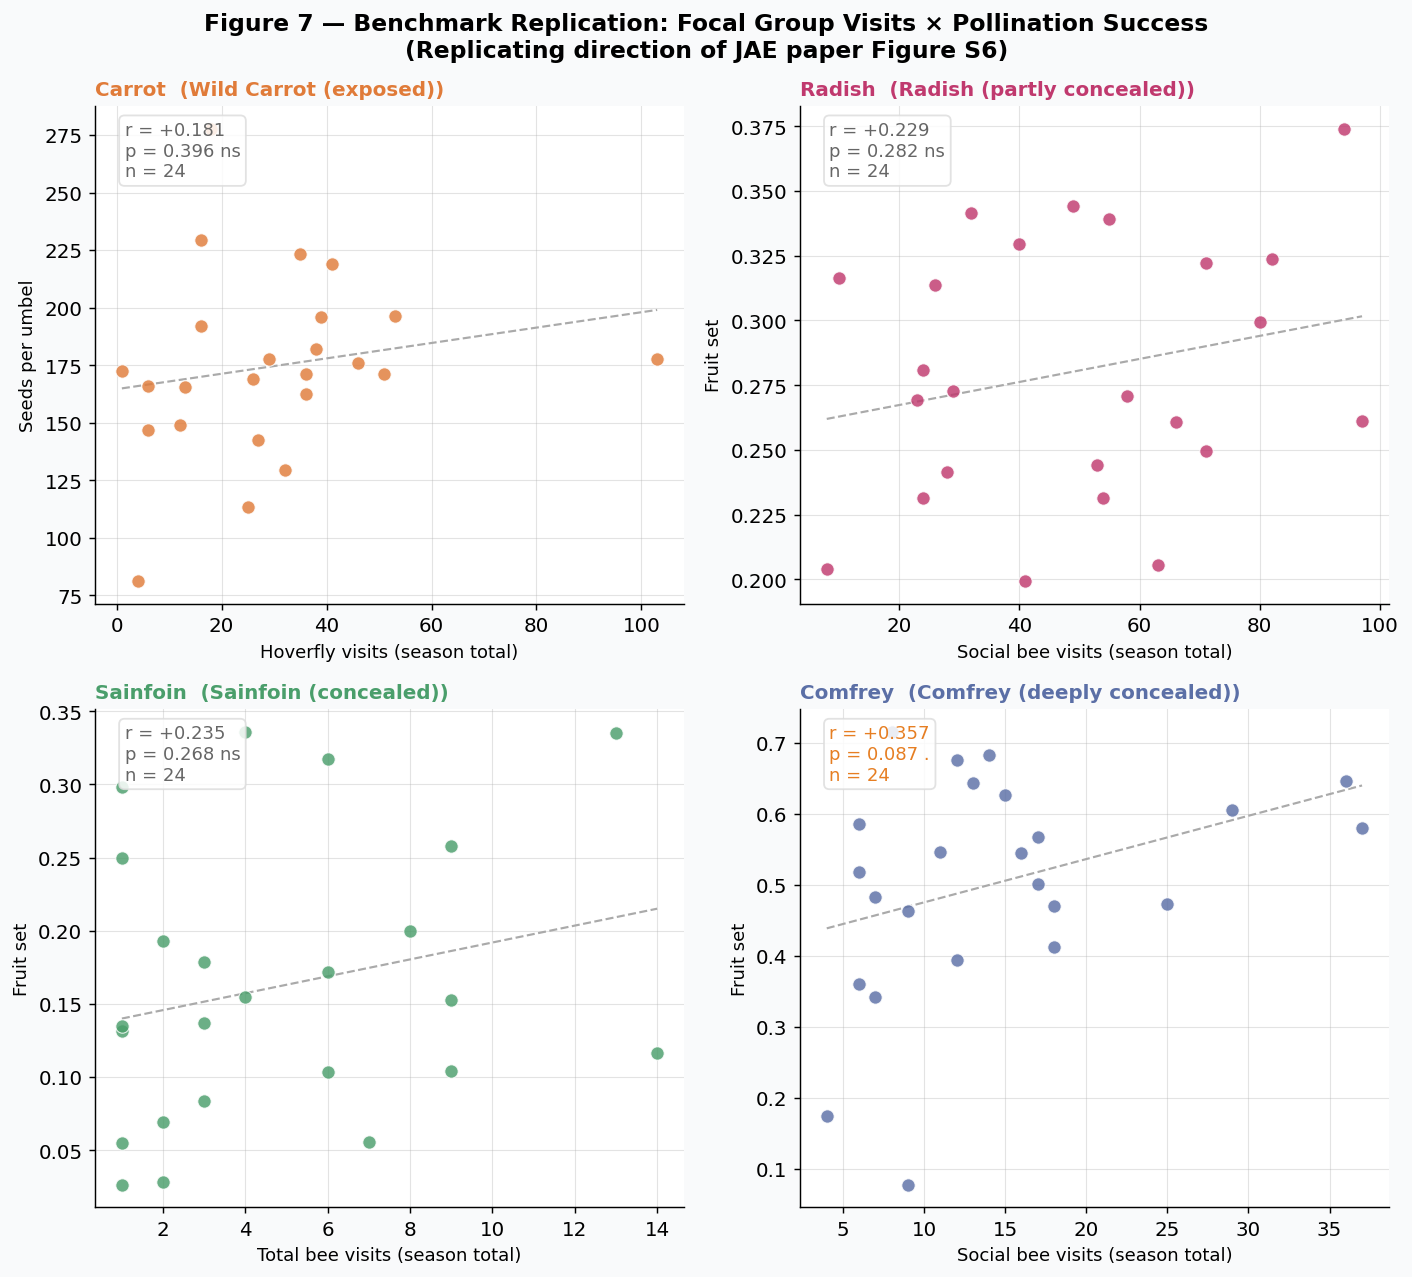

In [ ]:
BENCH_LABELS={'Carrot':'Hoverfly visits','Radish':'Social bee visits','Sainfoin':'Total bee visits','Comfrey':'Social bee visits'}
fig,axes=plt.subplots(2,2,figsize=(11,10))
fig.suptitle('Figure 4 — Benchmark Replication: JAE Figure S6 Direction',fontsize=13,fontweight='bold')
for ax,p in zip([axes[0,0],axes[0,1],axes[1,0],axes[1,1]],PLANT_ORDER):
    sub=master[master['phytometer_plant']==p].dropna(subset=['focal_group_visits_benchmark','pollination_success'])
    ax.scatter(sub['focal_group_visits_benchmark'],sub['pollination_success'],color=COLORS[p],s=55,alpha=0.82,edgecolors='white',linewidth=0.6,zorder=3)
    if len(sub)>=5:
        r,pv=stats.pearsonr(sub['focal_group_visits_benchmark'],sub['pollination_success'])
        xs=np.linspace(sub['focal_group_visits_benchmark'].min(),sub['focal_group_visits_benchmark'].max(),100)
        m,b=np.polyfit(sub['focal_group_visits_benchmark'],sub['pollination_success'],1)
        ls,lw=('-',1.8) if pv<0.05 else ('--',1.2)
        ax.plot(xs,m*xs+b,color=COLORS[p] if pv<0.05 else '#aaa',linewidth=lw,linestyle=ls,zorder=2)
        ann_r(ax,r,pv,len(sub))
    ax.set_title(f'{p}  ({PLANT_LABELS[p].replace(chr(10)," ")})',fontsize=11,fontweight='bold',color=COLORS[p],loc='left')
    ax.set_xlabel(BENCH_LABELS[p]+' (season total)',fontsize=10)
    ax.set_ylabel('Seeds per umbel' if p=='Carrot' else 'Fruit set',fontsize=10)
plt.tight_layout();plt.show()


## Figure 5 — Bee Tongue Length × Pollination Success (2×2 by Plant)

This is the primary figure of my novel analysis. I test whether the community-weighted mean (CWM) bee tongue length predicts garden-level pollination success, separately for each plant species. The theoretical prediction from trait-matching theory is clear: for flowers with deeply concealed nectar (comfrey), only long-tongued bees can reach the nectar and make legitimate contact with reproductive structures, so gardens visited by longer-tongued bee communities should achieve higher fruit set.

> **Expected:** Comfrey panel positive and significant. Carrot panel null. Solid line = p < 0.05; dashed = not significant.

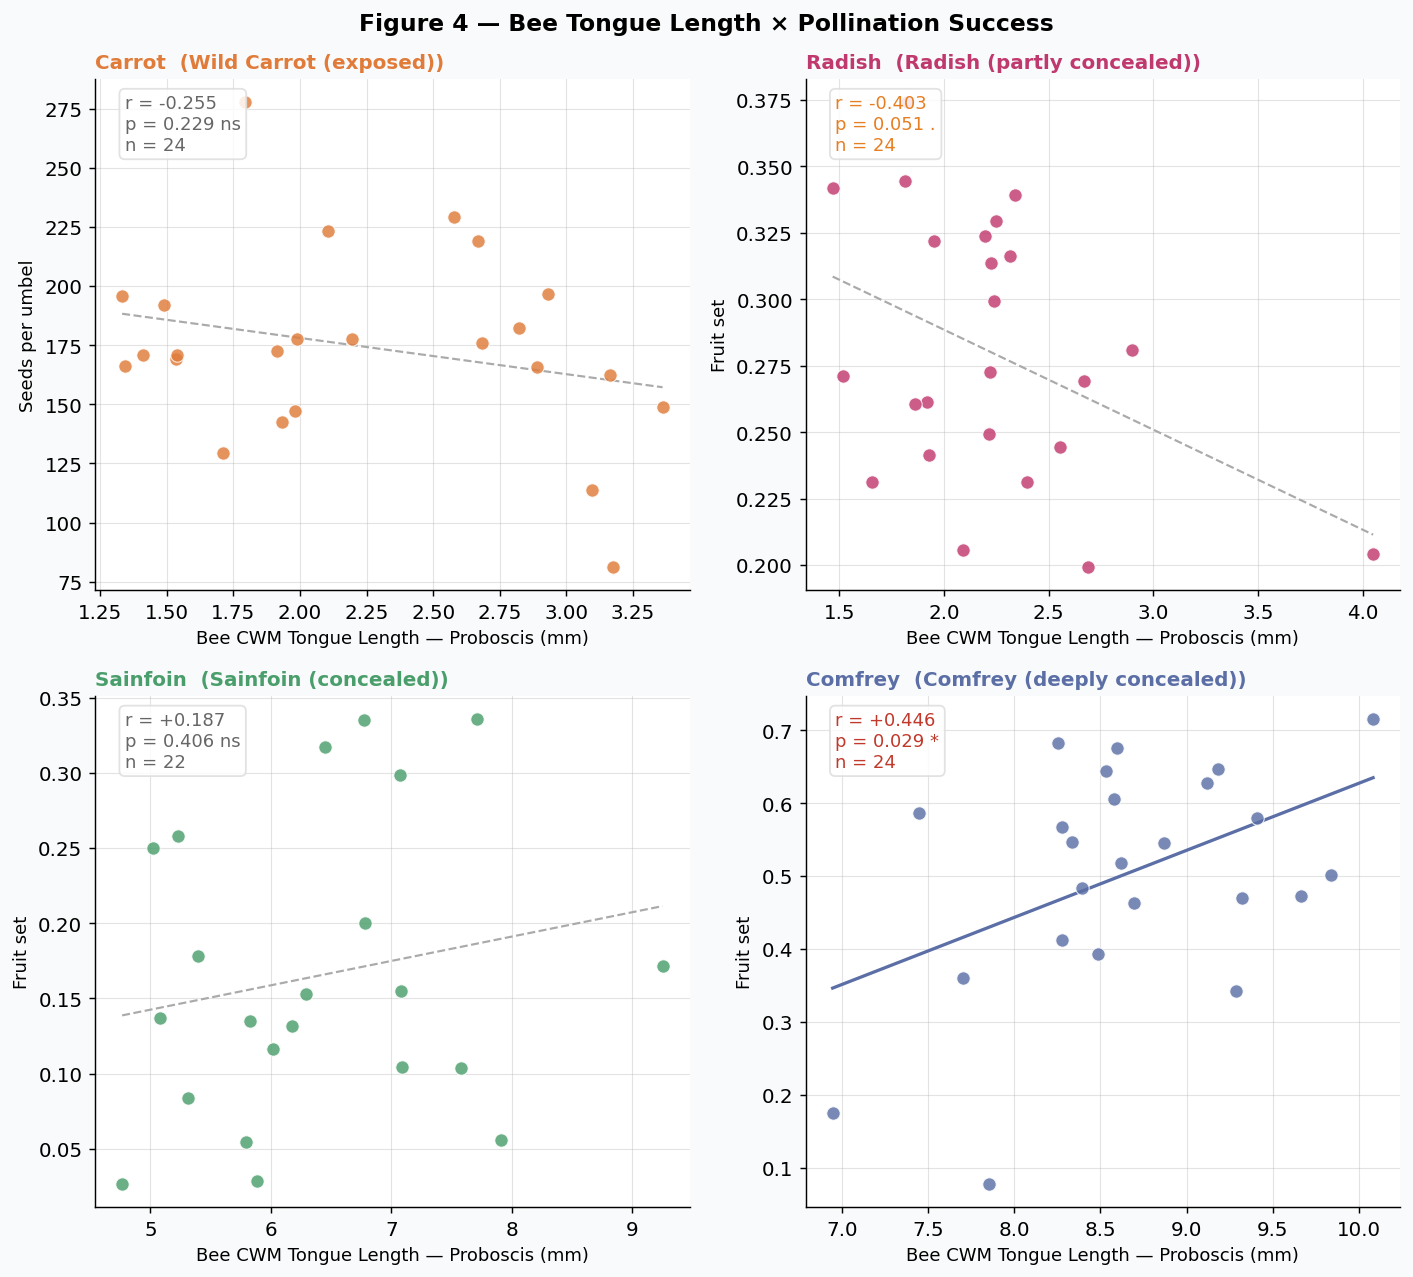

In [ ]:
xvar='bee_mean_proboscis_length'; xlabel='Bee CWM Tongue Length - Proboscis (mm)'
fig,axes=plt.subplots(2,2,figsize=(11,10))
fig.suptitle('Figure 5 - Bee Tongue Length x Pollination Success',fontsize=13,fontweight='bold')
for ax,p in zip([axes[0,0],axes[0,1],axes[1,0],axes[1,1]],PLANT_ORDER):
    sub=master[master['phytometer_plant']==p].dropna(subset=[xvar,'pollination_success'])
    ax.scatter(sub[xvar],sub['pollination_success'],color=COLORS[p],s=55,alpha=0.82,edgecolors='white',linewidth=0.6,zorder=3)
    if len(sub)>=5:
        r,pv=stats.pearsonr(sub[xvar],sub['pollination_success'])
        xs=np.linspace(sub[xvar].min(),sub[xvar].max(),100)
        m,b=np.polyfit(sub[xvar],sub['pollination_success'],1)
        ls,lw=('-',1.8) if pv<0.05 else ('--',1.2)
        ax.plot(xs,m*xs+b,color=COLORS[p] if pv<0.05 else '#aaa',linewidth=lw,linestyle=ls,zorder=2)
        ann_r(ax,r,pv,len(sub))
    ax.set_title(f'{p}  ({PLANT_LABELS[p].replace(chr(10)," ")})',fontsize=11,fontweight='bold',color=COLORS[p],loc='left')
    ax.set_xlabel(xlabel,fontsize=10)
    ax.set_ylabel('Seeds per umbel' if p=='Carrot' else 'Fruit set',fontsize=10)
plt.tight_layout();plt.show()


## Figure 6 — Bee Body Size × Pollination Success (2×2 by Plant)

I test bee CWM body size (intertegular distance) as a predictor. Body size covaries with tongue length across bee species, so comfrey and sainfoin may show a positive association because large bees (bumblebees) also tend to have long tongues. For radish, the direction is **exploratory** — I do not commit to a directional prediction without stronger prior literature support.

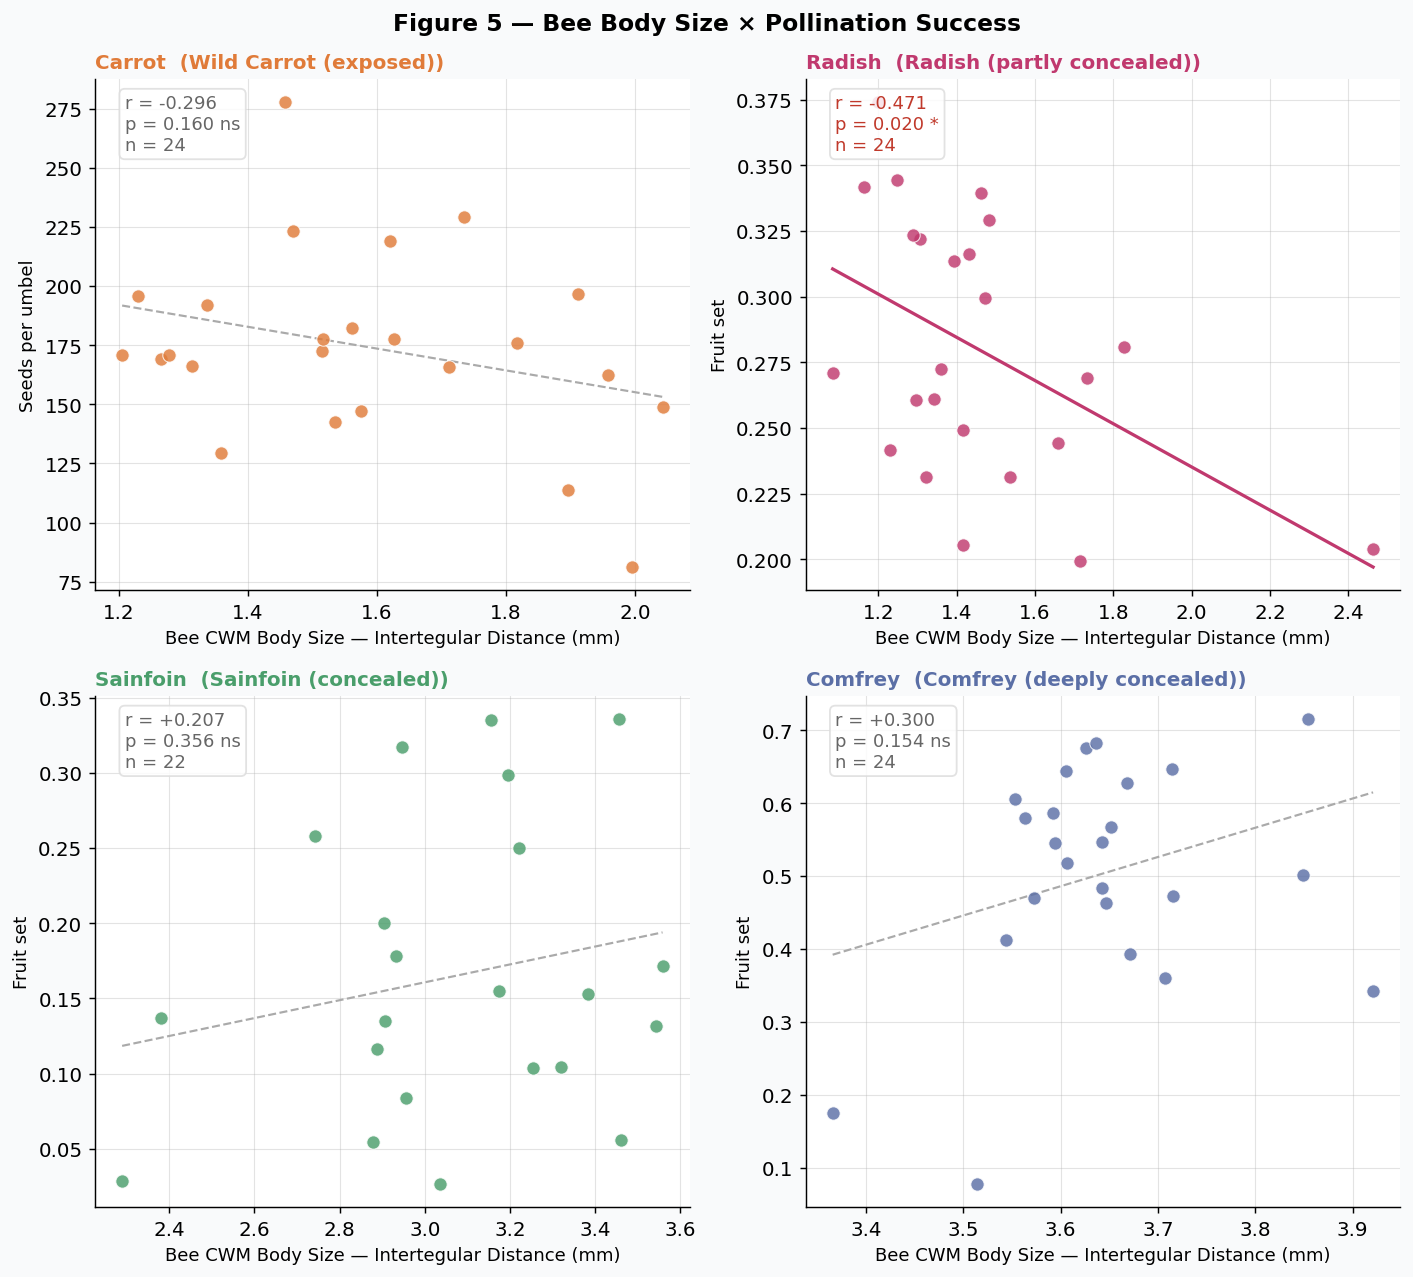

In [ ]:
xvar='bee_mean_intertegular_distance'; xlabel='Bee CWM Body Size - Intertegular Distance (mm)'
fig,axes=plt.subplots(2,2,figsize=(11,10))
fig.suptitle('Figure 6 - Bee Body Size x Pollination Success',fontsize=13,fontweight='bold')
for ax,p in zip([axes[0,0],axes[0,1],axes[1,0],axes[1,1]],PLANT_ORDER):
    sub=master[master['phytometer_plant']==p].dropna(subset=[xvar,'pollination_success'])
    ax.scatter(sub[xvar],sub['pollination_success'],color=COLORS[p],s=55,alpha=0.82,edgecolors='white',linewidth=0.6,zorder=3)
    if len(sub)>=5:
        r,pv=stats.pearsonr(sub[xvar],sub['pollination_success'])
        xs=np.linspace(sub[xvar].min(),sub[xvar].max(),100)
        m,b=np.polyfit(sub[xvar],sub['pollination_success'],1)
        ls,lw=('-',1.8) if pv<0.05 else ('--',1.2)
        ax.plot(xs,m*xs+b,color=COLORS[p] if pv<0.05 else '#aaa',linewidth=lw,linestyle=ls,zorder=2)
        ann_r(ax,r,pv,len(sub))
    ax.set_title(f'{p}  ({PLANT_LABELS[p].replace(chr(10)," ")})',fontsize=11,fontweight='bold',color=COLORS[p],loc='left')
    ax.set_xlabel(xlabel,fontsize=10)
    ax.set_ylabel('Seeds per umbel' if p=='Carrot' else 'Fruit set',fontsize=10)
plt.tight_layout();plt.show()


## Figure 7 — Social vs Solitary Bee Visits × Success (Comfrey and Radish)

I produce Figure 7 to bridge the abundance and trait analyses. If social bee visits predict success better than solitary bee visits for comfrey (left column) and radish (right column), this is consistent with both the JAE paper benchmark finding (social bee abundance = best predictor) and my trait interpretation (social bees = bumblebees = long-tongued = better on specialist flowers).

> **Expected:** Social bee visits show stronger positive correlation than solitary bee visits for comfrey. Both may be positive for radish but social bees should be stronger.

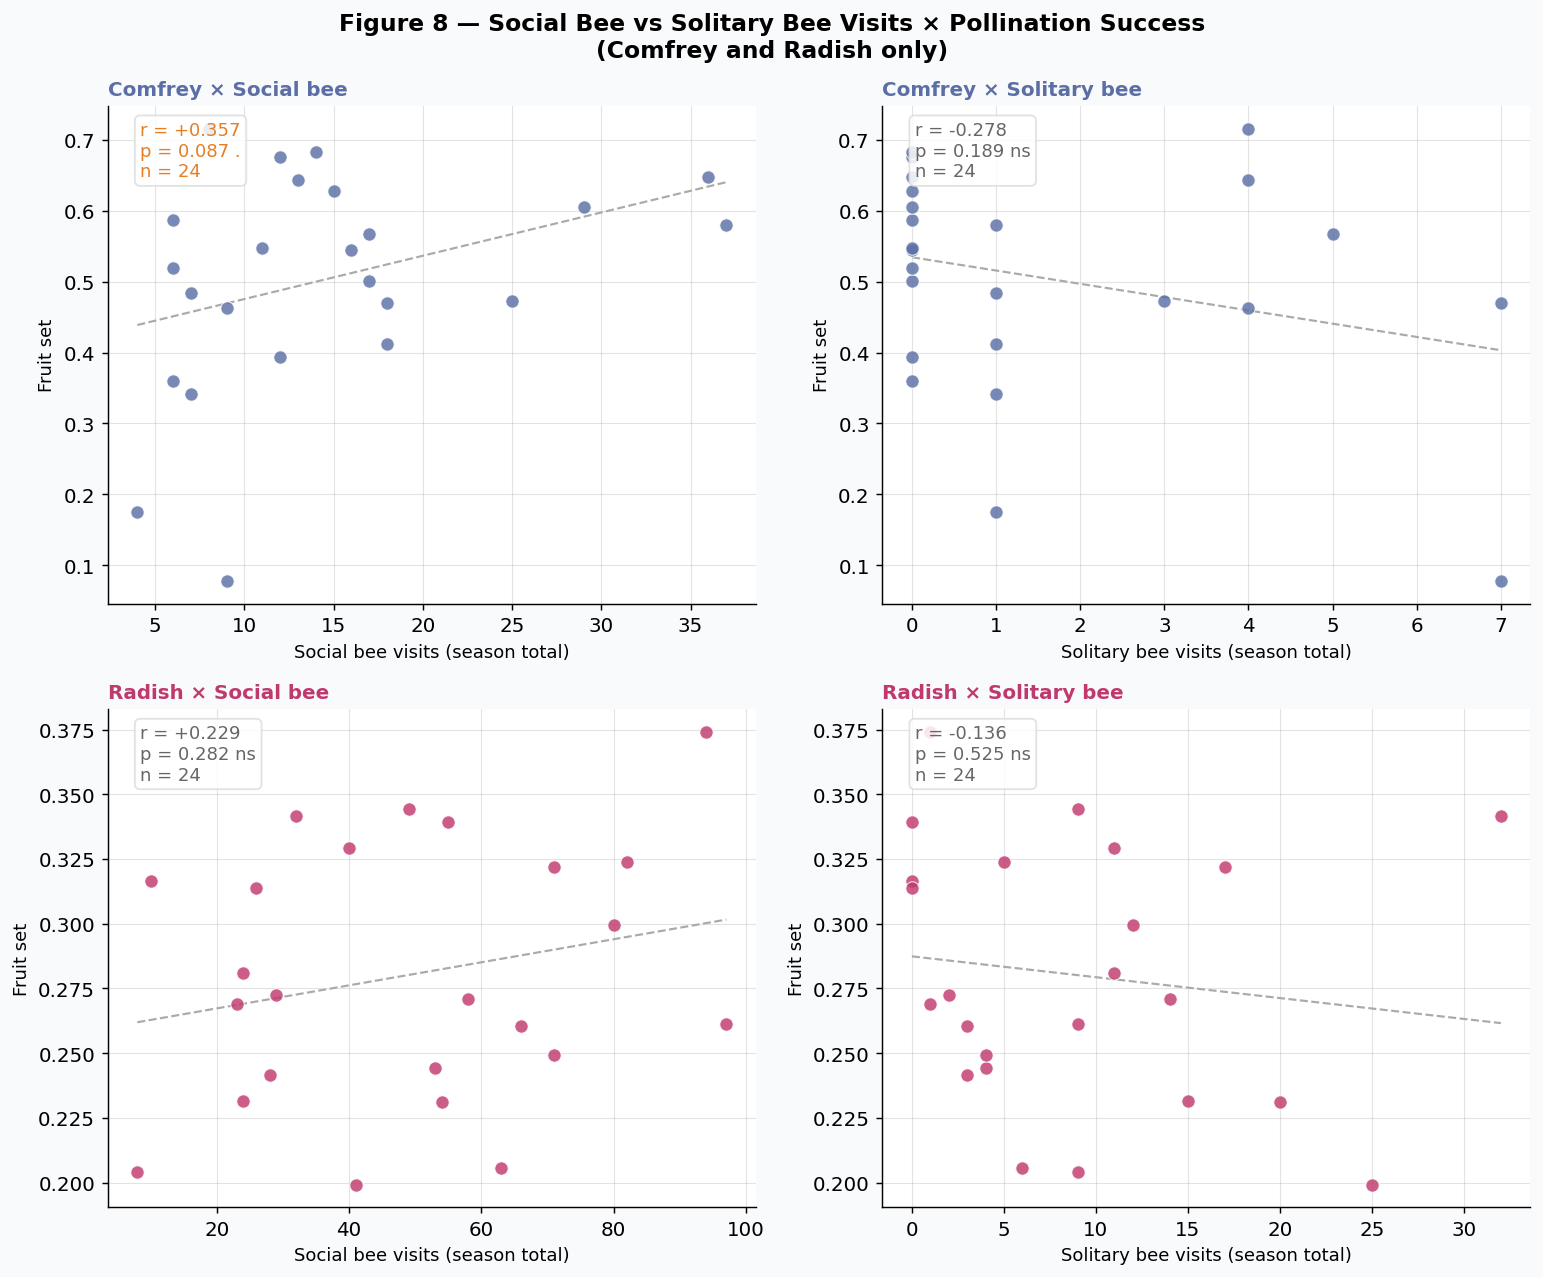

In [ ]:
plants_8=['Comfrey','Radish']; vars_8=[('social_bee_visits','Social bee visits'),('solitary_bee_visits','Solitary bee visits')]
fig,axes=plt.subplots(2,2,figsize=(12,10))
fig.suptitle('Figure 7 - Social vs Solitary Bee Visits x Pollination Success',fontsize=13,fontweight='bold')
for ri,plant in enumerate(plants_8):
    for ci,(var,label) in enumerate(vars_8):
        ax=axes[ri,ci]
        sub=master[master['phytometer_plant']==plant].dropna(subset=[var,'pollination_success'])
        ax.scatter(sub[var],sub['pollination_success'],color=COLORS[plant],s=55,alpha=0.82,edgecolors='white',linewidth=0.6,zorder=3)
        if len(sub)>=5:
            r,pv=stats.pearsonr(sub[var],sub['pollination_success'])
            xs=np.linspace(sub[var].min(),sub[var].max(),100)
            m,b=np.polyfit(sub[var],sub['pollination_success'],1)
            ax.plot(xs,m*xs+b,color=COLORS[plant] if pv<0.05 else '#aaa',linewidth=1.8 if pv<0.05 else 1.2,linestyle='-' if pv<0.05 else '--',zorder=2)
            ann_r(ax,r,pv,len(sub))
        ax.set_title(f'{plant} x {label}',fontsize=11,fontweight='bold',color=COLORS[plant],loc='left')
        ax.set_xlabel(label+' (season total)',fontsize=10);ax.set_ylabel('Fruit set',fontsize=10)
plt.tight_layout();plt.show()


## Figure 8 — Temporal Visitation Patterns and Morning Ratio × Success

I produce Figure 8 to explore a dimension not analysed in the JAE paper or data publication, despite the hourly temporal data being explicitly flagged as an opportunity. **Panel A** shows mean hourly visitation patterns by plant. **Panel B** shows the strongest temporal association I find: radish morning visit fraction predicts fruit set (r = +0.56, p = 0.004), making it the single strongest predictor in my study. I note morning flower receptivity as a possible mechanism while acknowledging the data cannot confirm this.

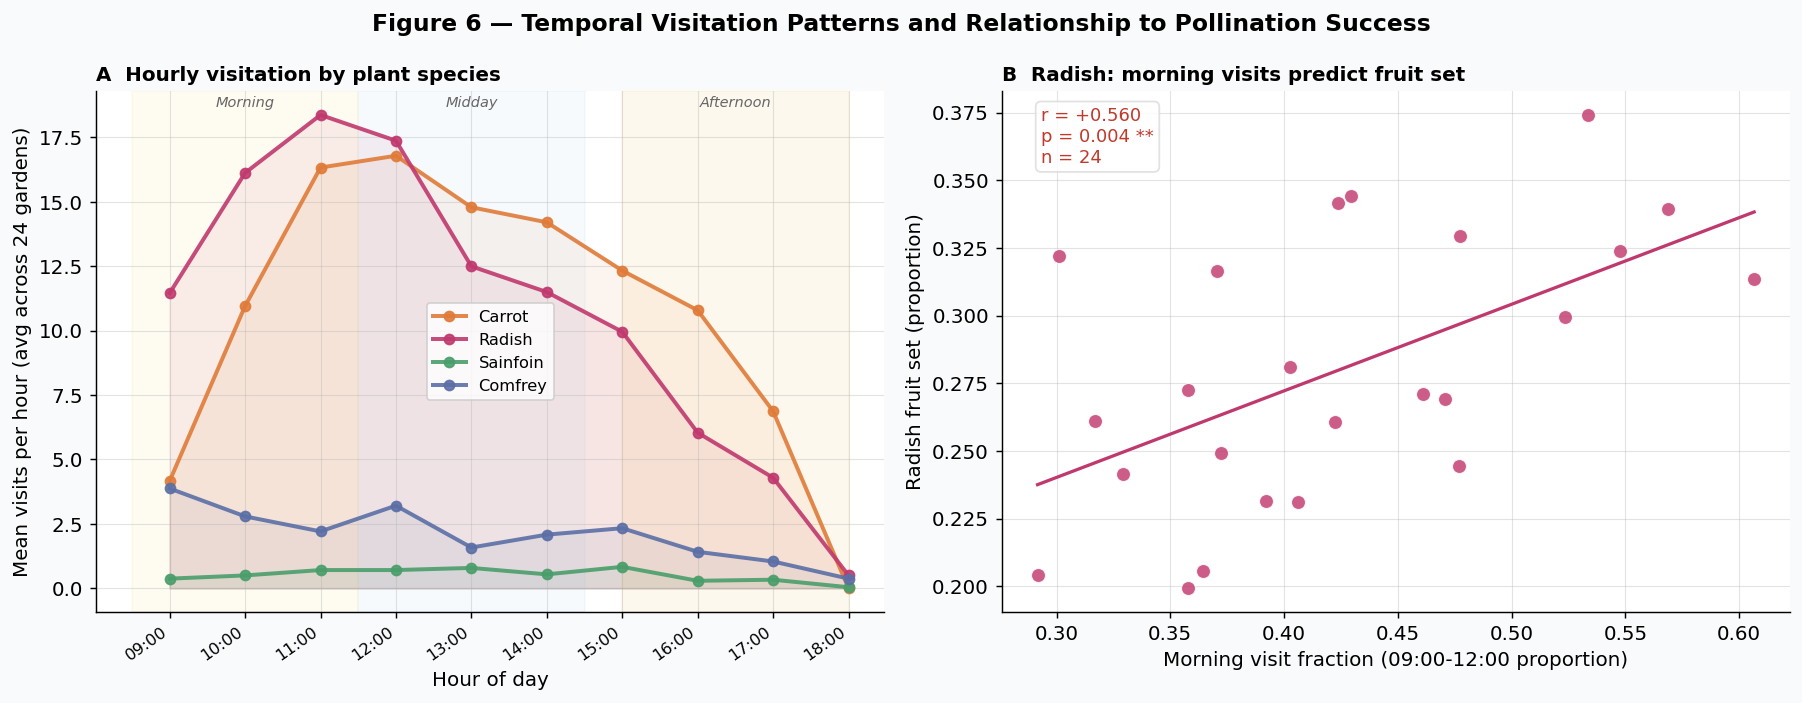

In [ ]:
# Load hourly data
DATA_DIR='pollinator_data'
vis_raw=pd.read_csv(f'{DATA_DIR}/06_trait_data/species_temporal_flower_visitation_matrix.csv')
vis2=vis_raw.rename(columns={'Id':'garden_id'})
META2=['garden_id','phytometer_plant','capture_date','capture_window']
TAXA2=[c for c in vis2.columns if c not in META2]
vis2['wv']=vis2[TAXA2].sum(axis=1)
wt=vis2.groupby(['garden_id','phytometer_plant','capture_window'])['wv'].sum().reset_index()
wp=wt.groupby(['phytometer_plant','capture_window'])['wv'].mean().reset_index()
WIN_LABELS={1:'09',2:'10',3:'11',4:'12',5:'13',6:'14',7:'15',8:'16',9:'17',10:'18'}

fig,axes=plt.subplots(1,2,figsize=(14,5.5))
fig.suptitle('Figure 8 - Temporal Visitation Patterns and Morning Ratio x Success',fontsize=13,fontweight='bold')
ax=axes[0]
for p in PLANT_ORDER:
    sub=wp[wp['phytometer_plant']==p].sort_values('capture_window')
    ax.plot(sub['capture_window'],sub['wv'],color=COLORS[p],linewidth=2.2,marker='o',markersize=5.5,alpha=0.9,label=p)
    ax.fill_between(sub['capture_window'],sub['wv'],alpha=0.08,color=COLORS[p])
ax.set_xlabel('Hour of day');ax.set_ylabel('Mean visits per hour')
ax.set_title('A  Hourly visitation',fontsize=11,loc='left',fontweight='bold')
ax.set_xticks(list(WIN_LABELS.keys()));ax.set_xticklabels([f'{v}:00' for v in WIN_LABELS.values()],rotation=35,ha='right',fontsize=9)
ax.legend(fontsize=9)
subR=master[master['phytometer_plant']=='Radish'].dropna(subset=['morning_ratio','pollination_success'])
r_r,p_r=stats.pearsonr(subR['morning_ratio'],subR['pollination_success'])
m_r,b_r=np.polyfit(subR['morning_ratio'],subR['pollination_success'],1)
ax2=axes[1]
ax2.scatter(subR['morning_ratio'],subR['pollination_success'],color=COLORS['Radish'],s=60,alpha=0.82,edgecolors='white',linewidth=0.6,zorder=3)
xs_r=np.linspace(subR['morning_ratio'].min(),subR['morning_ratio'].max(),100)
ax2.plot(xs_r,m_r*xs_r+b_r,color=COLORS['Radish'],linewidth=1.8,zorder=2)
ann_r(ax2,r_r,p_r,len(subR))
ax2.set_xlabel('Morning visit fraction (09:00-12:00 proportion)');ax2.set_ylabel('Radish fruit set')
ax2.set_title('B  Radish: morning visits -> fruit set',fontsize=11,loc='left',fontweight='bold')
plt.tight_layout();plt.show()


## Table 1 — R² Comparison Across All Predictor Categories

Table 1 is the synthesis of my entire analysis. It shows the proportion of variance explained (R² = Pearson r²) for every predictor type and every plant in one place. The benchmark row appears first so I can immediately see whether my trait and temporal predictors exceed what the JAE paper's published abundance predictor achieves. Cells are colour-coded by significance level.

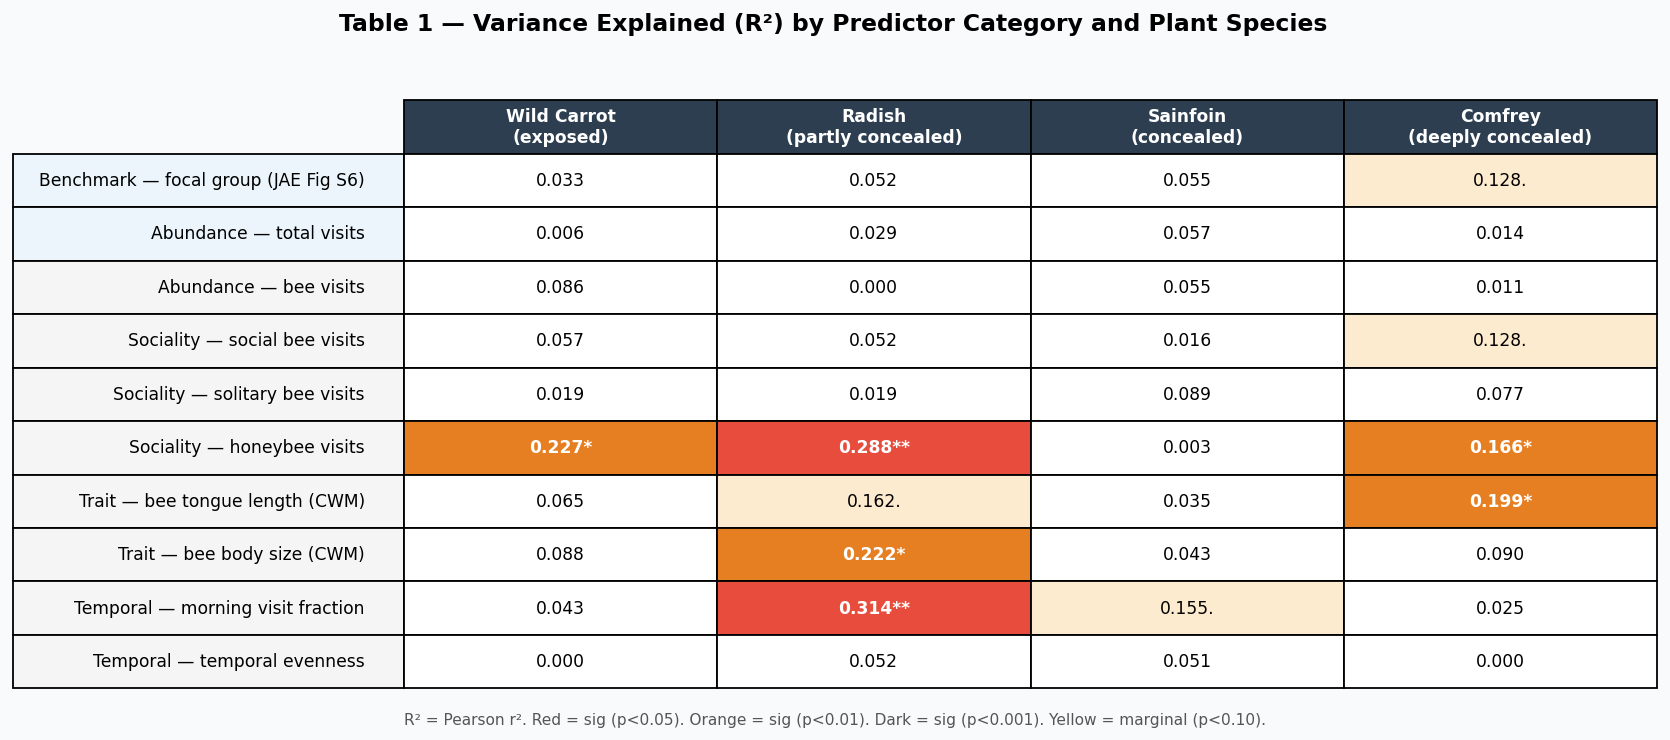

In [ ]:
preds=[('Benchmark (JAE Fig S6)','focal_group_visits_benchmark'),('Abundance - total','total_visits'),
       ('Abundance - bee','bee_visits'),('Sociality - social bee','social_bee_visits'),
       ('Sociality - solitary bee','solitary_bee_visits'),('Sociality - honeybee','honeybee_visits'),
       ('Trait - tongue (CWM)','bee_mean_proboscis_length'),('Trait - body size (CWM)','bee_mean_intertegular_distance'),
       ('Temporal - morning ratio','morning_ratio'),('Temporal - evenness','temporal_evenness')]
data_cells=[]; r_vals=[]
for lbl,var in preds:
    row=[]; rrow=[]
    for p in PLANT_ORDER:
        sub=master[master['phytometer_plant']==p].dropna(subset=[var,'pollination_success'])
        if len(sub)>=5:
            r,pv=stats.pearsonr(sub[var],sub['pollination_success'])
            sig='***' if pv<0.001 else '**' if pv<0.01 else '*' if pv<0.05 else '.' if pv<0.10 else ''
            row.append(f'{r**2:.3f}{sig}'); rrow.append((r**2,pv))
        else: row.append('--'); rrow.append((0,1))
    data_cells.append(row); r_vals.append(rrow)
fig,ax=plt.subplots(figsize=(13,5.5))
fig.suptitle('Table 1 - Variance Explained (R2) by Predictor Category',fontsize=13,fontweight='bold',y=1.03)
ax.axis('off')
col_labels=['Wild Carrot','Radish','Sainfoin','Comfrey']
tbl=ax.table(cellText=data_cells,rowLabels=[p[0] for p in preds],colLabels=col_labels,cellLoc='center',rowLoc='right',loc='center',bbox=[0,0,1,1])
tbl.auto_set_font_size(False);tbl.set_fontsize(9.5)
for j in range(4):tbl[0,j].set_facecolor('#2C3E50');tbl[0,j].set_text_props(color='white',fontweight='bold')
for i,rrow in enumerate(r_vals,1):
    tbl[i,-1].set_facecolor('#f5f5f5')
    for j,(r2,pv) in enumerate(rrow):
        if pv<0.001:tbl[i,j].set_facecolor('#C0392B');tbl[i,j].set_text_props(color='white',fontweight='bold')
        elif pv<0.01:tbl[i,j].set_facecolor('#E74C3C');tbl[i,j].set_text_props(color='white',fontweight='bold')
        elif pv<0.05:tbl[i,j].set_facecolor('#E67E22');tbl[i,j].set_text_props(color='white',fontweight='bold')
        elif pv<0.10:tbl[i,j].set_facecolor('#FDEBD0')
ax.text(0,-0.04,'R2 = Pearson r squared. Colour = significance level.',transform=ax.transAxes,fontsize=8.5,color='#555',va='top')
plt.tight_layout();plt.show()
